# ** Business Understanding **

A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies. The dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. The data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.

# ** Steps in conducting a hypothesis test: **
- Formulate the Null and Alternative Hypothesis
- Gather evidence(data)
- Calculate the test statistic
- Make a conclusion

In [76]:
# ** Importing Libraries **
import numpy as np 
import pandas as pd
from scipy import stats
from sklearn.datasets import load_iris

## ** Load Dataset **

In [17]:
dropout_df = pd.read_csv("data/drop_out.csv", sep=";")
dropout_df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [21]:
dropout_df.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,10,1,9773,1,1,152.0,22,38,37,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


In [87]:
dropout_df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [23]:
dropout_df.keys()

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [25]:
dropout_df['Target'].unique()

<StringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str

In [26]:
dropout_df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [29]:
dropout_df['GDP'].describe()

count    4424.000000
mean        0.001969
std         2.269935
min        -4.060000
25%        -1.700000
50%         0.320000
75%         1.790000
max         3.510000
Name: GDP, dtype: float64

In [88]:
dropout_df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [90]:
dropout_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [91]:
dropout_df.duplicated().sum()

np.int64(0)

In [92]:
dropout_df.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [27]:
dropout_df.describe(include='object')

/var/folders/0c/1j_h2q_d3cz5xx15_x7nbdyw0000gn/T/ipykernel_69306/1955925560.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dropout_df.describe(include='object')


,Target
count,4424
unique,3
top,Graduate
freq,2209


## ** Hypothesis: **

- Null(Ho): Target  == GDP
- alternative(Ha): Target != GDP

- parameter of interest is *mean*
- the groups are independent
- two tailed test
- ideal test statistic here is t-test

## ** Seperate the groups: **

In [40]:
Dropout = dropout_df[dropout_df['Target'] == 'Dropout']['GDP']
Graduate = dropout_df[dropout_df['Target'] == 'Graduate']['GDP']
Enrolled = dropout_df[dropout_df['Target'] == 'Enrolled']['GDP']

## ** Calculate the mean | standard deviation | size **

In [42]:
# length/ size of data sets
len_Dropout= len(Dropout) 
len_Graduate = len(Graduate)
len_Enrolled = len(Enrolled)


# mean
mean_Dropout = Dropout.mean()
mean_Graduate = Graduate.mean()
mean_Enrolled = Enrolled.mean()

# standard deviations
sd_Dropout = Dropout.std()
sd_Graduate = Graduate.std()
sd_Enrolled = Enrolled.std()

output_len = f"LEN** Dropout: {len_Dropout} |  Graduate: {len_Graduate}  | Enrolled: {len_Enrolled}"
output_mean = f"MEAN** Dropout: {mean_Dropout:.3f} |  Graduate: {mean_Graduate:.3f}  | Enrolled: {mean_Enrolled:.3f}"
output_sd = f"SD** Dropout: {sd_Dropout:.3f} |  Graduate: {sd_Graduate:.3f}  | Enrolled: {sd_Enrolled:.3f}"


print("=================================================")
print(output_len)
print(output_mean)
print(output_sd)

print("=================================================")

LEN** Dropout: 1421 |  Graduate: 2209  | Enrolled: 794
MEAN** Dropout: -0.151 |  Graduate: 0.082  | Enrolled: 0.053
SD** Dropout: 2.252 |  Graduate: 2.261  | Enrolled: 2.316


In [44]:
Dropout.describe()

count    1421.000000
mean       -0.150859
std         2.251768
min        -4.060000
25%        -1.700000
50%         0.320000
75%         1.740000
max         3.510000
Name: GDP, dtype: float64

In [45]:
Graduate.describe()

count    2209.000000
mean        0.081833
std         2.261081
min        -4.060000
25%        -1.700000
50%         0.790000
75%         1.790000
max         3.510000
Name: GDP, dtype: float64

In [46]:
Enrolled.describe()

count    794.000000
mean       0.053287
std        2.315631
min       -4.060000
25%       -1.700000
50%        0.320000
75%        1.790000
max        3.510000
Name: GDP, dtype: float64

## ** Calculate the Test Statistic **

## ** Graduate Vs Enrolled **

In [48]:
t_stat, p_value = stats.ttest_ind(Graduate, Enrolled)

In [49]:
output = f" Test Statistic {t_stat:.4f} | p-value: {p_value:.4f}"
print(output)

 Test Statistic 0.3032 | p-value: 0.7618


In [ ]:
## ** Conclusion/ Statistical Significance **

In [51]:
α = 0.05 # alpha

if p_value < α: 
    print("Reject Ho")
else:
    print("Fail to reject Ho")

Fail to reject Ho


## ** Insights **
- p-value = 0.7618 is much greater than the usual significance level α = 0.05.
- therefore I fail to reject the null hypothesis - Ho

## ** Enrolled Vs Dropout **

In [54]:
t_stat, p_value = stats.ttest_ind(Enrolled, Dropout)

In [55]:
output = f" Test Statistic {t_stat:.4f} | p-value: {p_value:.4f}"
print(output)

 Test Statistic 2.0254 | p-value: 0.0429


## ** Conclusion/ Statistical Significance **

In [56]:
α = 0.05 # alpha

if p_value < α: 
    print("Reject Ho")
else:
    print("Fail to reject Ho")

Reject Ho


## ** Insights **
- p-value = 0.0429 is less than the usual significance level α = 0.05.
- therefore I reject the null hypothesis - Ho
- This means there is statistically significant evidence that the mean GDP of the two groups is different.

## ** Visualization **

/var/folders/0c/1j_h2q_d3cz5xx15_x7nbdyw0000gn/T/ipykernel_69306/1335749795.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Dropout, shade=True, label="Dropout")
/var/folders/0c/1j_h2q_d3cz5xx15_x7nbdyw0000gn/T/ipykernel_69306/1335749795.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Graduate, shade=True, label="Graduate")
/var/folders/0c/1j_h2q_d3cz5xx15_x7nbdyw0000gn/T/ipykernel_69306/1335749795.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Enrolled, shade=True, label="Enrolled")


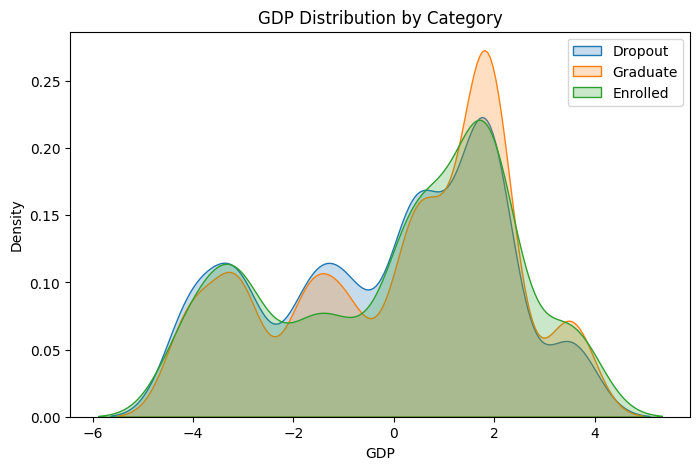

In [68]:
#Histogram / KDE Plot (Overlapping Distributions)
plt.figure(figsize=(8,5))

sns.kdeplot(Dropout, shade=True, label="Dropout")
sns.kdeplot(Graduate, shade=True, label="Graduate")
sns.kdeplot(Enrolled, shade=True, label="Enrolled")

plt.title("GDP Distribution by Category")
plt.xlabel("GDP")
plt.ylabel("Density")
plt.legend()
plt.show()